# Fase 2

# Subible 1

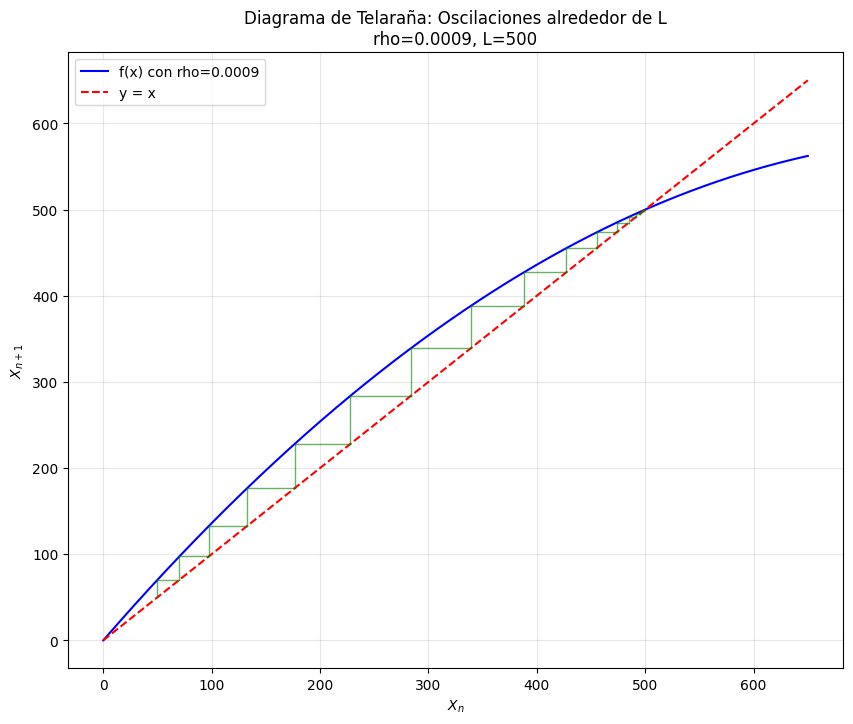

In [44]:
import numpy as np
import matplotlib.pyplot as plt

def modelo_logistico(x, rho, L):
    return x + rho * x * (L - x)

# Parámetros
rho_grande = 0.0009
L_fijo = 500
x0_inicial = 50
pasos = 30

# Visualización
x_range = np.linspace(0, L_fijo * 1.3, 500)
plt.figure(figsize=(10, 8))
plt.plot(x_range, modelo_logistico(x_range, rho_grande, L_fijo), 'b', label=f'f(x) con rho={rho_grande}')
plt.plot(x_range, x_range, 'r--', label='y = x')

x = x0_inicial
for i in range(pasos):
    y = modelo_logistico(x, rho_grande, L_fijo)
    plt.plot([x, x], [x, y], 'g', lw=1, alpha=0.6)
    plt.plot([x, y], [y, y], 'g', lw=1, alpha=0.6)
    x = y

plt.title(f'Diagrama de Telaraña: Oscilaciones alrededor de L\nrho={rho_grande}, L={L_fijo}')
plt.xlabel('$X_n$')
plt.ylabel('$X_{n+1}$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

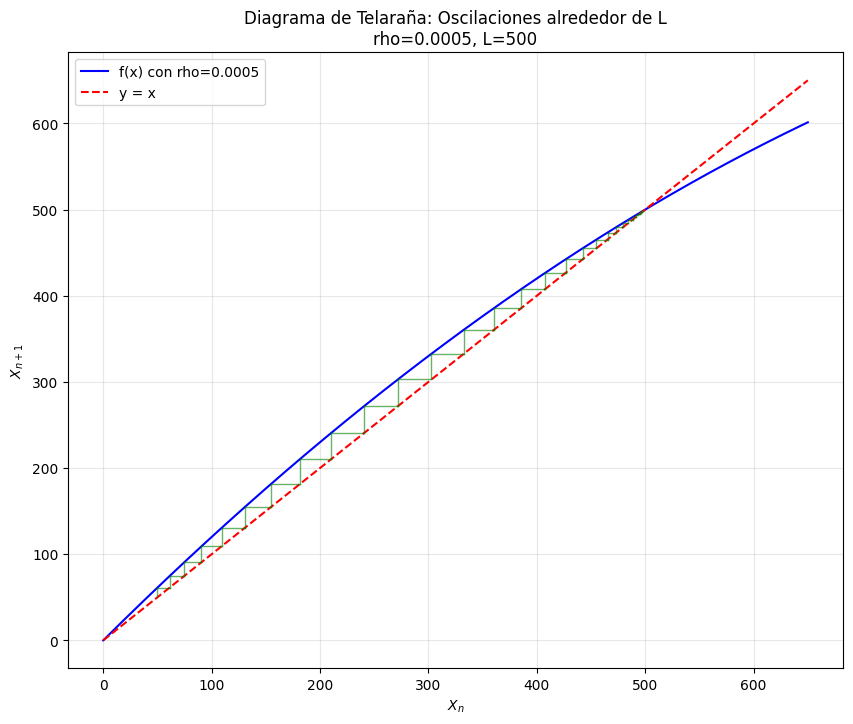

In [49]:
import numpy as np
import matplotlib.pyplot as plt

def modelo_logistico(x, rho, L):
    return x + rho * x * (L - x)

# Parámetros
rho_grande = 0.0005
L_fijo = 500
x0_inicial = 50
pasos = 30

# Visualización
x_range = np.linspace(0, L_fijo * 1.3, 500)
plt.figure(figsize=(10, 8))
plt.plot(x_range, modelo_logistico(x_range, rho_grande, L_fijo), 'b', label=f'f(x) con rho={rho_grande}')
plt.plot(x_range, x_range, 'r--', label='y = x')

x = x0_inicial
for i in range(pasos):
    y = modelo_logistico(x, rho_grande, L_fijo)
    plt.plot([x, x], [x, y], 'g', lw=1, alpha=0.6)
    plt.plot([x, y], [y, y], 'g', lw=1, alpha=0.6)
    x = y

plt.title(f'Diagrama de Telaraña: Oscilaciones alrededor de L\nrho={rho_grande}, L={L_fijo}')
plt.xlabel('$X_n$')
plt.ylabel('$X_{n+1}$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Subible 2

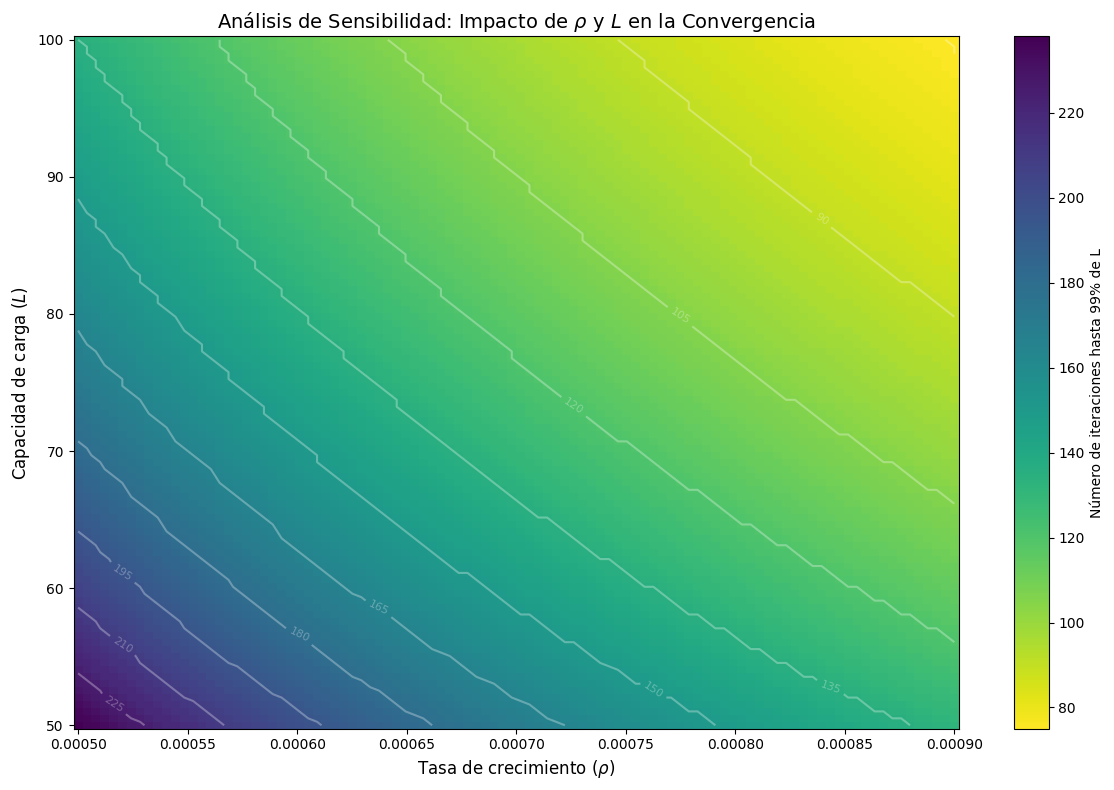

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

def calcular_iteraciones(rho, L, x0, target_pct=0.99, max_iter=500):
    """
    Calcula cuántos pasos toma llegar al 99% de la capacidad de carga.
    """
    x = x0
    for i in range(max_iter):
        if x <= 0 or np.isnan(x) or x > L * 2:
            return max_iter

        if x >= L * target_pct:
            return i

        # Ecuación logística discreta
        x = x + rho * x * (L - x)

    return max_iter
l_vec = np.linspace(100, 50, 100)
# Rho entre el valor pequeño (0.0005) y el alto (0.0009)
rho_vec = np.linspace(0.0005, 0.0009, 100)

# Generar la matriz de datos
Z = np.zeros((len(l_vec), len(rho_vec)))
X0 = 10

for i, L in enumerate(l_vec):
    for j, rho in enumerate(rho_vec):
        Z[i, j] = calcular_iteraciones(rho, L, X0)

plt.figure(figsize=(12, 8))
X, Y = np.meshgrid(rho_vec, l_vec)
pcm = plt.pcolormesh(X, Y, Z,
                     shading='auto',
                     cmap='viridis_r')

# Añadimos todo lo que sea necesartio para una buena visualización
contornos = plt.contour(X, Y, Z, levels=10, colors='white', alpha=0.3)
plt.clabel(contornos, inline=True, fontsize=8)
plt.colorbar(pcm, label='Número de iteraciones hasta 99% de L')
plt.title('Análisis de Sensibilidad: Impacto de $\\rho$ y $L$ en la Convergencia', fontsize=14)
plt.xlabel(r'Tasa de crecimiento ($\rho$)', fontsize=12)
plt.ylabel(r'Capacidad de carga ($L$)', fontsize=12)

# Cabe aclarar que a menor rho, el color será más intenso/claro indicando más tiempo
plt.tight_layout()
plt.show()

# Subible 3

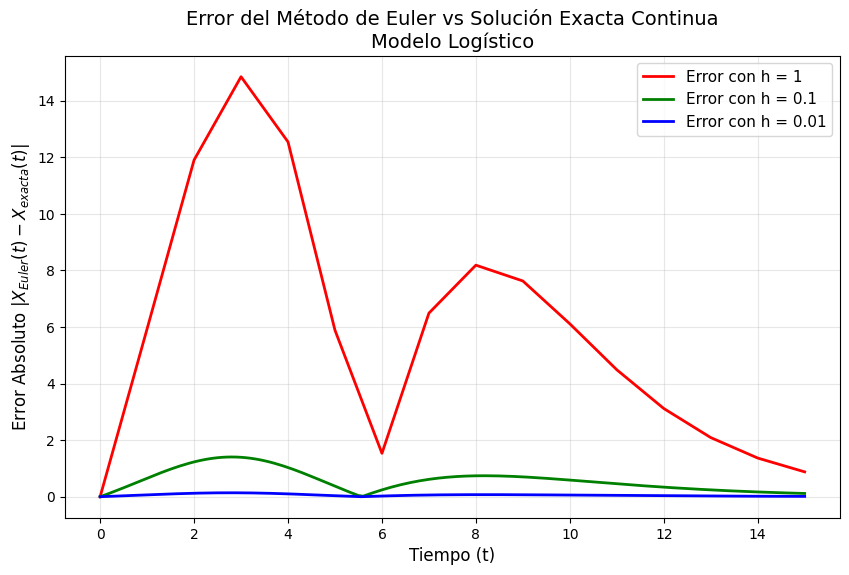

In [47]:
import numpy as np
import matplotlib.pyplot as plt

def solucion_exacta(t, alpha, L, x0):
    """Solución analítica exacta de la EDO logística continua."""
    C = (L - x0) / x0
    return L / (1 + C * np.exp(-alpha * t))

def euler_logistico(alpha, L, x0, t_end, h):
    """Aproximación numérica usando el Método de Euler."""
    t = np.arange(0, t_end + h, h)
    X = np.zeros(len(t))
    X[0] = x0

    for n in range(0, len(t) - 1):
        # Derivada en el instante actual: g(X)
        dX_dt = alpha * X[n] * (1 - X[n] / L)
        # Siguiente paso de Euler
        X[n+1] = X[n] + h * dX_dt

    return t, X

# Parametros de la simulación
alpha = 0.5  # Tasa de crecimiento
L = 500      # Capacidad de carga
x0 = 100     # Población inicial
t_end = 15   # Tiempo total a simular
pasos_h = [1, 0.1, 0.01]
colores = ['red', 'green', 'blue']

plt.figure(figsize=(10, 6))
for h, color in zip(pasos_h, colores):
    t_euler, X_euler = euler_logistico(alpha, L, x0, t_end, h)
    X_exacta = solucion_exacta(t_euler, alpha, L, x0)
    error_absoluto = np.abs(X_euler - X_exacta)
    plt.plot(t_euler, error_absoluto, color=color, linewidth=2, label=f'Error con h = {h}')

plt.title('Error del Método de Euler vs Solución Exacta Continua\nModelo Logístico', fontsize=14)
plt.xlabel('Tiempo (t)', fontsize=12)
plt.ylabel('Error Absoluto $|X_{Euler}(t) - X_{exacta}(t)|$', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.show()

# Subible 4


Cargamos la base de datos directamente desde su git RAW y gráficamos encontrando el error cúadratico medio (MSE) en comparación con los datos reales para ver la calidad del modelo.

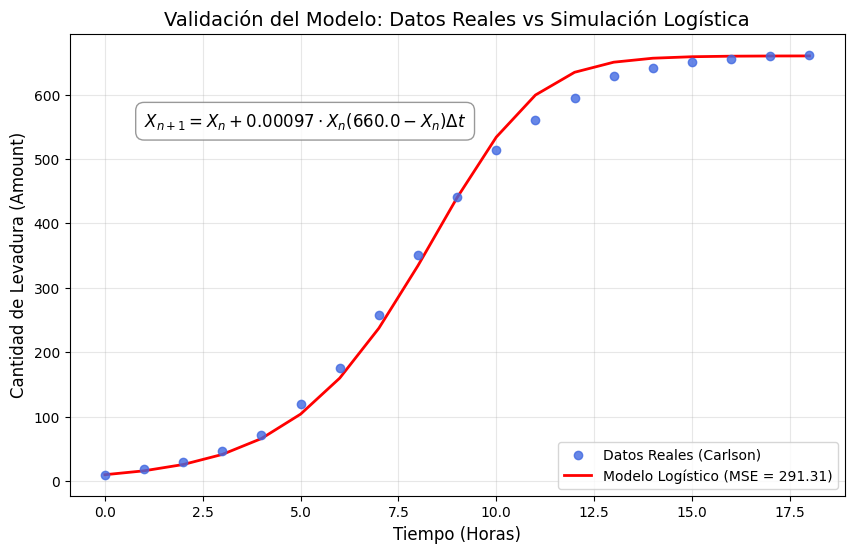


Resultados Numéricos:
Población Inicial (X0): 9.6
Error Cuadrático Medio (MSE): 291.3112


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#cargamos los datos desde github usando el RAWR del archivo
url_github = "https://raw.githubusercontent.com/zhimingkuang/Harvard-AM-115/refs/heads/main/05_model_fitting/carlson_yeast_data.csv"

try:
    df = pd.read_csv(url_github)


except Exception as e:
    print(f"Error al cargar los datos: {e}")
t_real = df['Hours'].values
x_real = df['Amount'].values

# Parámetros del modelo
L_opt = 660.0
rho_opt = 0.00097
# Tomamos la población inicial real del primer dato de la tabla
x0_inicial = x_real[0]

def simular_logistico(rho, L, x0, tiempos):
    x_sim = np.zeros(len(tiempos))
    x_sim[0] = x0

    for i in range(len(tiempos)-1):
        dt = tiempos[i+1] - tiempos[i]
        x_sim[i+1] = x_sim[i] + rho * x_sim[i] * (L - x_sim[i]) * dt

    return x_sim

# Cálculo de la simulación y del Error Cuadrático Medio (MSE)
x_modelo = simular_logistico(rho_opt, L_opt, x0_inicial, t_real)
mse = np.mean((x_real - x_modelo)**2)

plt.figure(figsize=(10, 6))

# Graficamos los datos reales como puntos
plt.scatter(t_real, x_real, color='royalblue', alpha=0.8, label='Datos Reales (Carlson)', zorder=5)

# Graficamos la simulación como una línea continua, añadimos también  la ecuacion que estamos utilizando
plt.plot(t_real, x_modelo, 'r-', linewidth=2, label=f'Modelo Logístico (MSE = {mse:.2f})')

ecuacion_texto = r"$X_{n+1} = X_n + " + str(rho_opt) + r" \cdot X_n (" + str(L_opt) + r" - X_n) \Delta t$"
plt.text(1, 550, ecuacion_texto, fontsize=12,
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.5'))

plt.title('Validación del Modelo: Datos Reales vs Simulación Logística', fontsize=14)
plt.xlabel('Tiempo (Horas)', fontsize=12)
plt.ylabel('Cantidad de Levadura (Amount)', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.show()

print(f"\nResultados Numéricos:")
print(f"Población Inicial (X0): {x0_inicial}")
print(f"Error Cuadrático Medio (MSE): {mse:.4f}")